In [11]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats

In [12]:
clades = ["na_avian", "eurasian_avian"]
host_trees = {}

total_host_switch = {}
host_switch_pairs = {}

for clade in clades:
    
    tree_file = f'trees/{clade}/summary_baltic.nwk'
    traits_file = f'trees/{clade}/traits.json'

    with open(traits_file) as f:
        traits = json.load(f)

    mytree = bt.loadNewick(tree_file, absoluteTime=False)
    host_trees[clade] = mytree
    
    node_traits = traits["nodes"]
    
    total_host_switch[clade] = 0
    host_switch_pairs[clade] = defaultdict(int)

    for k in mytree.Objects:
        name = k.traits["label"] if k.is_node() else k.name
        k.traits["order"] = node_traits[name]["order"]

    for k in mytree.Objects:
        if k.is_node() and k.parent.traits != {}:  
            parent_order = k.parent.traits.get("order")
            child_order = k.traits.get("order")
            
            focal_orders = ["galliformes", "anseriformes", "charadriiformes"]
            if parent_order != child_order and (parent_order in focal_orders) and (child_order in focal_orders):
                total_host_switch[clade] += 1
                host_switch_pairs[clade][(parent_order, child_order)] += 1

for clade in clades:
    print(f"{clade}: {total_host_switch[clade]} total switches")
    for pair, count in host_switch_pairs[clade].items():
        print(f"  {pair}: {count}")

na_avian: 7 total switches
  ('anseriformes', 'charadriiformes'): 7
eurasian_avian: 38 total switches
  ('anseriformes', 'galliformes'): 13
  ('galliformes', 'anseriformes'): 14
  ('anseriformes', 'charadriiformes'): 7
  ('charadriiformes', 'anseriformes'): 4


In [13]:
total_host_switch

{'na_avian': 7, 'eurasian_avian': 38}

In [14]:
host_trees

{'na_avian': <baltic.baltic.tree at 0x321572560>,
 'eurasian_avian': <baltic.baltic.tree at 0x321e989d0>}

# Nodes only, checking parent

In [15]:
# only nodes, checking parent

rea_switches = {clade: {} for clade in host_trees.keys()}
rea_no_switches = {clade: {} for clade in host_trees.keys()}
clonal_switches = {clade: {} for clade in host_trees.keys()}
clonal_no_switches = {clade: {} for clade in host_trees.keys()}

host_switches_json = {clade: {} for clade in clades}

for clade in clades:

    host_switch_rea = no_switch_rea = 0
    host_switch_clonal = no_switch_clonal = 0
    
    host_switches = defaultdict(int)

    for k in host_trees[clade].Objects:

        if k.is_node() and  k.traits['is_reassorted']:

            if k.parent.traits['order'] == k.traits['order']:
                no_switch_rea += 1

            elif (k.parent.traits['order'] in ["galliformes", "anseriformes", "charadriiformes"]) and (k.traits['order'] in ["galliformes", "anseriformes", "charadriiformes"]):
                host_switch_rea += 1
                host_switches[(k.parent.traits['order'], k.traits['order'])] += 1

        if k.is_node() and k.parent.traits and not k.traits['is_reassorted']:

            if k.parent.traits['order'] == k.traits['order']:
                no_switch_clonal += 1

            elif (k.parent.traits['order'] in ["galliformes", "anseriformes", "charadriiformes"]) and (k.traits['order'] in ["galliformes", "anseriformes", "charadriiformes"]):
                host_switch_clonal += 1
                
    host_switches_json[clade] = {
            (parent, child): count
            for (parent, child), count in host_switches.items()
        }
                
    rea_switches[clade] = host_switch_rea
    clonal_switches[clade] = host_switch_clonal

    rea_no_switches[clade] = no_switch_rea
    clonal_no_switches[clade] = no_switch_clonal


In [16]:
host_switches_json

{'na_avian': {('anseriformes', 'charadriiformes'): 1},
 'eurasian_avian': {('anseriformes', 'galliformes'): 5,
  ('galliformes', 'anseriformes'): 3,
  ('charadriiformes', 'anseriformes'): 1}}

In [17]:
print(rea_switches, rea_no_switches)
print(clonal_switches, clonal_no_switches)

{'na_avian': 1, 'eurasian_avian': 9} {'na_avian': 301, 'eurasian_avian': 188}
{'na_avian': 6, 'eurasian_avian': 29} {'na_avian': 877, 'eurasian_avian': 657}


In [18]:
# fitness analysis FET

p_values = []
odds_ratios = []
confidence = []

for clade in clades:

    a = rea_switches[clade]
    b = rea_no_switches[clade]
    c = clonal_switches[clade]
    d = clonal_no_switches[clade]

    table = [[a, b], [c, d]]

    odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

    if a > 0 and b > 0 and c > 0 and d > 0:
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        log_or = math.log(odds_ratio)
        ci_low = math.exp(log_or - 1.96 * se_log_or)
        ci_high = math.exp(log_or + 1.96 * se_log_or)
    else:
        print(f"one of your counts are 0")
        ci_low, ci_high = float('nan'), float('nan')

    odds_ratios.append(odds_ratio)
    p_values.append(p_value)
    confidence.append((ci_low, ci_high))

    print(f"{clade} p-value = {p_value:.8f}, odds ratio = {odds_ratio:.2f}, 95% CI = {ci_low, ci_high}")

na_avian p-value = 0.68569485, odds ratio = 0.49, 95% CI = (0.05822446273983309, 4.050029671368884)
eurasian_avian p-value = 0.84256547, odds ratio = 1.08, 95% CI = (0.5045588723917313, 2.3312680743979675)


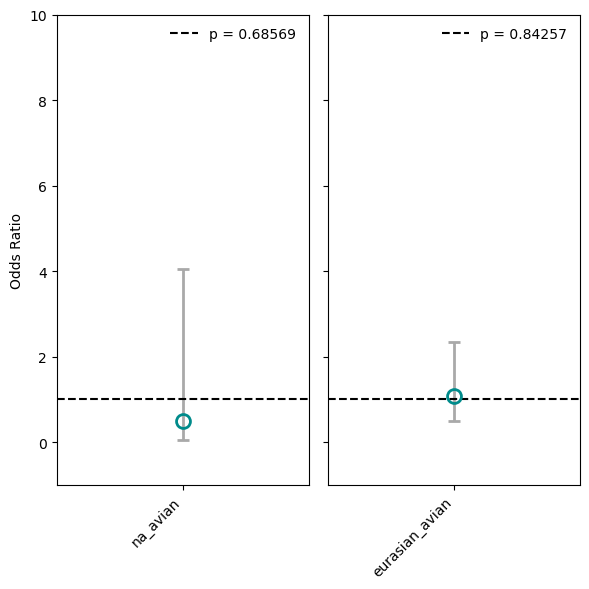

In [19]:
num_clades = len(clades)
fig, axes = plt.subplots(1, num_clades, figsize=(num_clades * 3, 6), sharey=True)

for ax, clade, odds_ratio, p_value, (ci_low, ci_high) in zip(
        axes, clades, odds_ratios, p_values, confidence):

    #  error bars
    lower_err = odds_ratio - ci_low
    upper_err = ci_high - odds_ratio
    error_bars = [[lower_err], [upper_err]]

    ax.errorbar(
        [0], [odds_ratio],
        yerr=error_bars,
        fmt='o',
        color='darkcyan',
        ecolor='darkgrey',
        elinewidth=2,
        capsize=4,
        markersize=10,
        markerfacecolor='none',   # not significant
        markeredgewidth=2
    )

    ax.axhline(1, color='black', linestyle='--')

    ax.set_xticks([0])
    ax.set_xticklabels([clade], rotation=45, ha='right')
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 10) 

    ax.legend([f"p = {p_value:.5f}"], loc='upper right', frameon=False)

axes[0].set_ylabel("Odds Ratio")

plt.tight_layout()
plt.savefig(f"plots/avian_order_switches_OR.pdf", dpi=300, bbox_inches="tight")
plt.show()


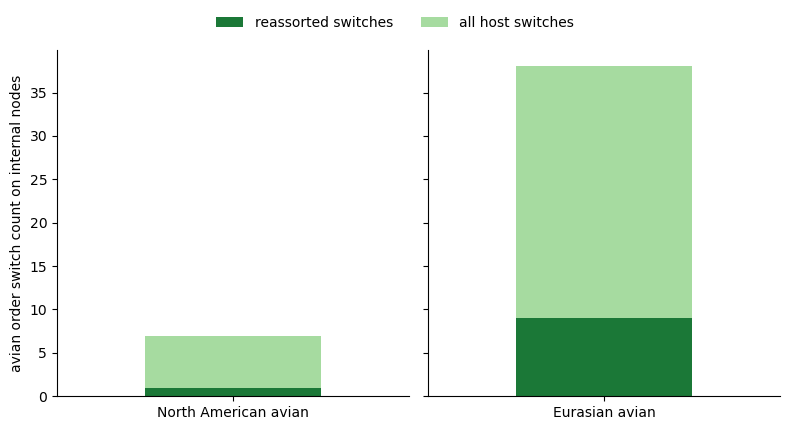

In [ ]:
categories = ["na_avian", "eurasian_avian"]
titles = ["North American avian", "Eurasian avian"]

total_vals = [total_host_switch.get(c,0) for c in categories]
subset_vals = [rea_switches.get(c,0) for c in categories]
remainder_vals = [t - s for t, s in zip(total_vals, subset_vals)]

width = 0.6

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8,4), sharey=True)

axes = [ax1, ax2]

for i, ax in enumerate(axes):

    subset = subset_vals[i]
    remainder = remainder_vals[i]

    # bottom portion
    ax.bar(
        0,
        subset,
        width,
        color="#1B7837",
        linewidth=1.2,
        label="reassorted switches"
    )

    # stacked top portion
    ax.bar(
        0,
        remainder,
        width,
        bottom=subset,
        color="#A6DBA0",
        linewidth=1.2,
        label="all host switches"
    )

    ax.set_xticks([0])
    ax.set_xticklabels([titles[i]])

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xlim(-0.6, 0.6)

ax1.set_ylabel("avian order switch count on internal nodes")

fig.legend(
    ["reassorted switches", "all host switches"],
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.08),
    ncol=2
)


plt.tight_layout()
plt.savefig(f"plots/avian_order_switches_rea.pdf", dpi=300, bbox_inches="tight")
plt.show()